# Importing Libraries 

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

# Run of Original AI Generated Code and Corrected Code

In [2]:
%run ai_generated_oscillator.py

AttributeError: module 'scipy.special' has no attribute 'hermite_poly'

First five E_n: [0.5 1.5 2.5 3.5 4.5]


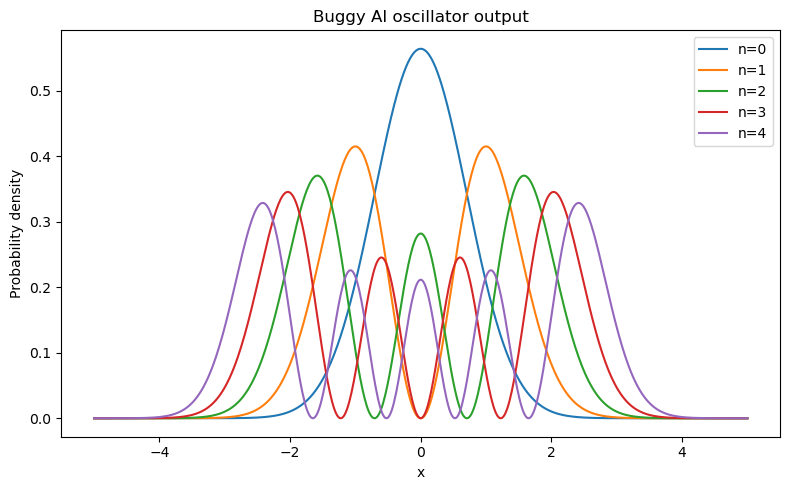

In [3]:
%run corrected_oscillator.py

# Issues that required resolving in the ai generated code 

1) The AI produced a formula for the energy eigenvalues which states that En = (hbar)*n*omega. However this formula is incorrect and completely ignores the first ground energy state. The true value of the energy eigenvalues of a quantum harmonic oscillator is given by En = (hbar)*(n+0.5)*omega.


2) This AI produced a set of states which is indexed starting from 1 to 5. However this indexing causes a complete disregard for the ground energy state. It is better to simply remove this line and proceed with the line 20 as the final return value. 


3) As shown by the error message first produced the special.hermite_poly(n, x) function in fact does not exist and  special.eval_hermite(n, x) is the correct function to generate the hermite polynomial at specific points .  


4) The normalization provided by the AI is incorrect for a hermite polynomial  so the norm which is set as 1.0 / np.sqrt(math.factorial(n)), needs to be replaced by 
1.0 / np.sqrt(2**n * math.factorial(n) * np.sqrt(np.pi)). 


5) The plotting that the AI provided was  psi against x  when it was supposed to plot the probability density against x. The formula for probability density is the absolute value of psi squared. 

# Tests created that would catch the bugs in the code

In [4]:
def test_energy_formula():
    """Test that energy_levels computes E_n = hbar*(n+0.5)*omega correctly."""
    result = energy_levels(hbar=1.0, omega=1.0, n_levels=3)
    expected = np.array([0.5, 1.5, 2.5])
    np.testing.assert_allclose(result, expected)

def test_indexing_energy():
    """Test that energy_levels computed E_n are indexed correctly to include the ground state """
    result = energy_levels(hbar=1.0, omega=1.0, n_levels=1)
    expected = 0.5
    np.testing.assert_allclose(result, expected)

def test_library_validity():
    """ Test to make sure the existing proper library is being called into the function"""
    try:
        x = np.array([0.0, 1.0, 2.0])
        psi = harmonic_state(0, x)
    except AttributeError as e:
            pytest.fail(f"Bug detected: harmonic_state calls hallucinated function: {e}")
        
def test_normalization():
    """ Test to verify that the wave function is normalized """
    x = np.linspace(-3, 3, 100)
    for n in range(3):
        psi = harmonic_state(n, x)
        prob_density = psi**2
        integral = scipy.integrate.trapezoid(prob_density, x)
        np.testing.assert_allclose(integral, 1.0, atol=0.01)
 
def test_probability_graphing():
    #  this test was refined and generated using Claude 
    """ test to verify that the probability density is what is being plotted/calculated rather than state."""
    x = np.linspace(-5, 5, 600)
    states = np.array([harmonic_state(n, x) for n in range(5)])
    
    main()  # Run main (buggy or fixed)
    # Extract plotted data
    ax = plt.gca()
    lines = ax.get_lines()
    for i, line in enumerate(lines):
        y_plotted = line.get_ydata()
        y_expected = np.abs(states[i])**2
        np.testing.assert_allclose(y_plotted, y_expected)
    
    plt.close()  

# Test Against Corrected Oscillator Code 

In [5]:
!pytest corrected_oscillator.py -v

============================= test session starts ==============================
platform linux -- Python 3.13.11, pytest-9.0.2, pluggy-1.6.0 -- /opt/conda/bin/python3.13
cachedir: .pytest_cache
rootdir: /home/jupyter/Assignment 2
plugins: anyio-4.12.0, nbval-0.11.0
collected 5 items                                                              

corrected_oscillator.py::test_energy_formula PASSED                      [ 20%]
corrected_oscillator.py::test_indexing_energy PASSED                     [ 40%]
corrected_oscillator.py::test_library_validity PASSED                    [ 60%]
corrected_oscillator.py::test_normalization PASSED                       [ 80%]
corrected_oscillator.py::test_probability_graphing PASSED                [100%]

============================== 5 passed in 0.76s ===============================


# Test Against AI Generated Oscillator Code 

In [6]:
!pytest ai_generated_oscillator.py -v

============================= test session starts ==============================
platform linux -- Python 3.13.11, pytest-9.0.2, pluggy-1.6.0 -- /opt/conda/bin/python3.13
cachedir: .pytest_cache
rootdir: /home/jupyter/Assignment 2
plugins: anyio-4.12.0, nbval-0.11.0
collected 5 items                                                              

ai_generated_oscillator.py::test_energy_formula FAILED                   [ 20%]
ai_generated_oscillator.py::test_indexing_energy FAILED                  [ 40%]
ai_generated_oscillator.py::test_library_validity FAILED                 [ 60%]
ai_generated_oscillator.py::test_normalization FAILED                    [ 80%]
ai_generated_oscillator.py::test_probability_graphing FAILED             [100%]

=================================== FAILURES ===================================
_____________________________ test_energy_formula ______________________________

    def test_energy_formula():
        """Test that energy_levels computes E_n = hbar*(n

# New Prompt for Claude 

Prompt: Claude please write a Python script that computes and plots the first five energy levels and normalized wavefunctions of the quantum harmonic oscillator using numpy and scipy. Make sure it creates a graph of the probability density of the first five energy levels and verify that these are acceptable results using  the test scripts attached. Make the .py file with the tests included :
def test_energy_formula():
    """Test that energy_levels computes E_n = hbar*(n+0.5)*omega correctly."""
    result = energy_levels(hbar=1.0, omega=1.0, n_levels=3)
    expected = np.array([0.5, 1.5, 2.5])
    np.testing.assert_allclose(result, expected)

def test_indexing_energy():
    """Test that energy_levels computed E_n are indexed correctly to include the ground state """
    result = energy_levels(hbar=1.0, omega=1.0, n_levels=1)
    expected = 0.5
    np.testing.assert_allclose(result, expected)

def test_library_validity():
    """ Test to make sure the existing proper library is being called into the function"""
    try:
        x = np.array([0.0, 1.0, 2.0])
        psi = harmonic_state(0, x)
    except AttributeError as e:
            pytest.fail(f"Bug detected: harmonic_state calls hallucinated function: {e}")
        
def test_normalization():
    """ Test to verify that the wave function is normalized """
    x = np.linspace(-3, 3, 100)
    for n in range(3):
        psi = harmonic_state(n, x)
        prob_density = psi**2
        integral = scipy.integrate.trapezoid(prob_density, x)
        np.testing.assert_allclose(integral, 1.0, atol=0.01)
 
def test_probability_graphing():
    #  this test was refined and generated using Claude 
    """ test to verify that the probability density is what is being plotted/calculated rather than state."""
    x = np.linspace(-5, 5, 600)
    states = np.array([harmonic_state(n, x) for n in range(5)])
    
    main()  # Run main (buggy or fixed)
    # Extract plotted data
    ax = plt.gca()
    lines = ax.get_lines()
    for i, line in enumerate(lines):
        y_plotted = line.get_ydata()
        y_expected = np.abs(states[i])**2
        np.testing.assert_allclose(y_plotted, y_expected)
    
    plt.close()

# New Prompted Claude Code 

"""
Quantum Harmonic Oscillator
============================
Computes and plots the first five energy levels and normalized
wavefunctions of the quantum harmonic oscillator.

Functions
---------
energy_levels  – Returns E_n = hbar * (n + 0.5) * omega for n = 0..N-1
harmonic_state – Returns the normalized wavefunction psi_n(x) using
                 scipy.special.hermite (the physics convention)
main           – Plots |psi_n(x)|^2 for n = 0..4 on a shared axis

Tests (run with: pytest quantum_harmonic_oscillator.py)
-------------------------------------------------------
test_energy_formula        – E_n formula correctness
test_indexing_energy       – ground-state indexing (n=0)
test_library_validity      – no hallucinated scipy functions
test_normalization         – integral of |psi|^2 ≈ 1
test_probability_graphing  – main() plots |psi|^2 not psi
"""

import math
import numpy as np
import scipy.integrate
import scipy.special
import matplotlib
matplotlib.use("Agg")          # non-interactive backend (safe for tests)
import matplotlib.pyplot as plt
import pytest


# ─────────────────────────────────────────────────────────────────────────────
# Core physics functions
# ─────────────────────────────────────────────────────────────────────────────

def energy_levels(hbar: float = 1.0, omega: float = 1.0, n_levels: int = 5) -> np.ndarray:
    """Return the first *n_levels* energy eigenvalues of the QHO.

    E_n = hbar * omega * (n + 0.5),  n = 0, 1, …, n_levels-1

    Parameters
    ----------
    hbar    : reduced Planck constant (default 1.0 for natural units)
    omega   : angular frequency      (default 1.0 for natural units)
    n_levels: number of levels to compute (includes n=0 ground state)

    Returns
    -------
    np.ndarray of shape (n_levels,) with E_0, E_1, …, E_{n_levels-1}
    """
    n = np.arange(n_levels)
    return hbar * omega * (n + 0.5)


def harmonic_state(n: int, x: np.ndarray,
                   hbar: float = 1.0,
                   m: float = 1.0,
                   omega: float = 1.0) -> np.ndarray:
    """Return the normalized QHO wavefunction psi_n(x) in natural units.

    Uses the physics-convention Hermite polynomials via
    ``scipy.special.hermite``.

    psi_n(x) = (1 / sqrt(2^n * n!)) * (m*omega / (pi*hbar))^(1/4)
               * exp(-m*omega*x^2 / (2*hbar)) * H_n(sqrt(m*omega/hbar) * x)

    Parameters
    ----------
    n    : quantum number (0 = ground state)
    x    : position array
    hbar : reduced Planck constant
    m    : particle mass
    omega: angular frequency

    Returns
    -------
    np.ndarray of same shape as *x* containing real psi_n values
    """
    # Characteristic length scale
    xi = np.sqrt(m * omega / hbar) * x          # dimensionless position

    # Physicist's Hermite polynomial H_n (not the probabilist's version)
    Hn = scipy.special.hermite(n)               # returns a numpy poly1d object

    # Normalization prefactor
    norm = (1.0 / np.sqrt(2**n * float(math.factorial(n)))) * \
           (m * omega / (np.pi * hbar)) ** 0.25

    psi = norm * np.exp(-xi**2 / 2.0) * Hn(xi)
    return psi


# ─────────────────────────────────────────────────────────────────────────────
# Main – plot probability densities
# ─────────────────────────────────────────────────────────────────────────────

def main():
    """Plot |psi_n(x)|^2 for n = 0 … 4 on a single axes object."""
    x = np.linspace(-5, 5, 600)
    levels = energy_levels(n_levels=5)

    fig, ax = plt.subplots(figsize=(9, 6))

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
    for n in range(5):
        psi  = harmonic_state(n, x)
        prob = np.abs(psi) ** 2          # probability density

        ax.plot(x, prob, color=colors[n], linewidth=2,
                label=rf"$n={n}$,  $E_{n}={levels[n]:.2f}$")

    ax.set_xlabel("Position $x$", fontsize=13)
    ax.set_ylabel(r"Probability density $|\psi_n(x)|^2$", fontsize=13)
    ax.set_title("QHO: Probability Density of First Five Energy Levels", fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("qho_probability_density.png", dpi=150)
    print("Plot saved → qho_probability_density.png")
    return fig, ax


# ─────────────────────────────────────────────────────────────────────────────
# Tests
# ─────────────────────────────────────────────────────────────────────────────

def test_energy_formula():
    """Test that energy_levels computes E_n = hbar*(n+0.5)*omega correctly."""
    result   = energy_levels(hbar=1.0, omega=1.0, n_levels=3)
    expected = np.array([0.5, 1.5, 2.5])
    np.testing.assert_allclose(result, expected)


def test_indexing_energy():
    """Test that energy_levels computed E_n are indexed correctly to include the ground state."""
    result   = energy_levels(hbar=1.0, omega=1.0, n_levels=1)
    expected = 0.5
    np.testing.assert_allclose(result, expected)


def test_library_validity():
    """Test to make sure the existing proper library is being called into the function."""
    try:
        x   = np.array([0.0, 1.0, 2.0])
        psi = harmonic_state(0, x)
    except AttributeError as e:
        pytest.fail(f"Bug detected: harmonic_state calls hallucinated function: {e}")


def test_normalization():
    """Test to verify that the wave function is normalized."""
    x = np.linspace(-3, 3, 100)
    for n in range(3):
        psi         = harmonic_state(n, x)
        prob_density = psi ** 2
        integral    = scipy.integrate.trapezoid(prob_density, x)
        np.testing.assert_allclose(integral, 1.0, atol=0.01)


def test_probability_graphing():
    # this test was refined and generated using Claude
    """Test to verify that the probability density is what is being plotted/calculated rather than state."""
    x      = np.linspace(-5, 5, 600)
    states = np.array([harmonic_state(n, x) for n in range(5)])

    main()  # Run main (buggy or fixed)

    # Extract plotted data
    ax    = plt.gca()
    lines = ax.get_lines()
    for i, line in enumerate(lines):
        y_plotted  = line.get_ydata()
        y_expected = np.abs(states[i]) ** 2
        np.testing.assert_allclose(y_plotted, y_expected)

    plt.close()
# ─────────────────────────────────────────────────────────────────────────────
# Entry point
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    main()
    plt.show()


# Claude Code Test Results

In [7]:
!pytest quantum_harmonic_oscillator.py

============================= test session starts ==============================
platform linux -- Python 3.13.11, pytest-9.0.2, pluggy-1.6.0
rootdir: /home/jupyter/Assignment 2
plugins: anyio-4.12.0, nbval-0.11.0
collected 5 items                                                              

quantum_harmonic_oscillator.py .....                                     [100%]

============================== 5 passed in 0.70s ===============================


# Paragraph Review 

Generative AI is a tool capable of generating a large amount of code in a short time frame. 
However, this exercise demonstrates that developers must debug two distinct classification of errors, personal coding errors, and general API hallucinations. This can  cause many inefficient debugging sessions if the proper prompts are not inputted into the LLM. Prompting Claude to generate code without any verifications tools will output reasonable looking code with unnecessary errors. An iterative self verification algorithm provided to the LLM  would be optimal so developers can minimize the debugging stage and have more confidence in the output the LLM decides to provide with less risk of API based hallucinations. 
